# 📝 ITDS251 ML Midterm Practice — Fill in the Blanks

> ฝึกเขียนเองทั้งหมด! แต่ละช่องมีคำใบ้ให้ ลองเขียนดูก่อนแล้วค่อยเทียบกับ Cheatsheet

---

## 📦 Part 1: Imports

เขียน import ทั้งหมดที่ใช้ในวิชานี้ให้ครบ

In [514]:
# === พื้นฐาน ===
# import numpy
import numpy as np
# import pandas
import pandas as pd
# import matplotlib
import matplotlib.pyplot as plt
# import seaborn
import seaborn as sns


In [515]:
# === แบ่งข้อมูล & ปรับสเกล ===
from sklearn.model_selection import train_test_split
# cross_val_score
from sklearn.model_selection import cross_val_score        # Cross-Validation
# StratifiedKFold
from sklearn.model_selection import StratifiedKFold        # แบ่ง fold แบบรักษาสัดส่วน class
# StandardScaler
from sklearn.preprocessing import StandardScaler          # ปรับสเกลข้อมูล (mean=0, std=1)
# MinMaxScaler
from sklearn.preprocessing import MinMaxScaler            # ปรับสเกลข้อมูล (min=0, max=1)
# PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures      # สร้าง feature ใหม่จาก feature ที่มีอยู่
# LabelEncoder
from sklearn.preprocessing import LabelEncoder            # แปลงข้อมูลเป็นตัวเลข


In [516]:
# === Regression Models ===
# LinearRegression
from sklearn.linear_model import LinearRegression          # Linear Regression
# Ridge
from sklearn.linear_model import Ridge
# Lasso
from sklearn.linear_model import Lasso
# ElasticNet
from sklearn.linear_model import ElasticNet                # ElasticNet (L1+L2 regularization)
# DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor             # Decision Tree (Regression)
# SVR
from sklearn.svm import SVR
# RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor


In [517]:
# === Classification Models ===
# KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
# DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
# export_text (แสดง tree rules)
from sklearn.tree import export_text
# LogisticRegression
from sklearn.linear_model import LogisticRegression        # Logistic Regression
# SVC
from sklearn.svm import SVC
# RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier


In [518]:
# === Evaluation Metrics ===
# Regression: mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Regression
# Classification: accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report
# Clustering: silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
# Distance: cosine, euclidean (จาก scipy)
from scipy.spatial.distance import cosine, euclidean       # คำนวณระยะทาง (L8)

In [519]:
# === Deep Learning (Keras/TensorFlow) ===
import tensorflow as tf
from tensorflow import keras
# Sequential
from tensorflow.keras.models import Sequential             # สร้างโมเดลแบบ Sequential
# Dense, Dropout
from tensorflow.keras.layers import Dense, Dropout         # Layer ชนิดต่างๆ
# Adam, SGD (optimizers)
from tensorflow.keras.optimizers import Adam, SGD
# to_categorical
from tensorflow.keras.utils import to_categorical


---
## 📊 Part 2: Pandas — อ่านและดูข้อมูล

In [520]:
# อ่านไฟล์ CSV (ใช้ car-sales-missing-data.csv)
df = pd.read_csv("car-sales-missing-data.csv")
df.to_csv("output.csv", index=False)       # เขียนออกไฟล์ CSV

In [521]:
# ดู 5 แถวแรก
df.head()

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"


In [522]:
# ดู 3 แถวสุดท้าย
df.tail(3)

,Make,Colour,Odometer,Doors,Price
7,Honda,Blue,NaN,4.0,NaN
8,Toyota,White,60000.0,NaN,NaN
9,NaN,White,31600.0,4.0,"$9,700"


In [523]:
# ดูข้อมูลทั่วไป (ประเภท, non-null)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Make      9 non-null      object 
 1   Colour    9 non-null      object 
 2   Odometer  6 non-null      float64
 3   Doors     9 non-null      float64
 4   Price     8 non-null      object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [524]:
# ดูสถิติ (mean, std, min, max)
df.describe()

,Odometer,Doors
count,6.000000,9.0
mean,92302.666667,4.0
std,76489.805168,0.5
min,11179.000000,3.0
25%,38700.000000,4.0
50%,73949.500000,4.0
75%,134507.000000,4.0
max,213095.000000,5.0


In [525]:
# ดู shape ของ DataFrame (กี่แถว x กี่คอลัมน์)
df.shape

(10, 5)

In [526]:
# ดูประเภทข้อมูลแต่ละคอลัมน์
df.dtypes

Make         object
Colour       object
Odometer    float64
Doors       float64
Price        object
dtype: object

In [527]:
# ดูชื่อคอลัมน์ทั้งหมด
df.columns

Index(['Make', 'Colour', 'Odometer', 'Doors', 'Price'], dtype='object')

### เลือกข้อมูล

In [528]:
# เลือก 1 คอลัมน์ (ได้ Series)
df["Make"]

0    Toyota
1     Honda
2    Toyota
3       BMW
4    Nissan
5    Toyota
6     Honda
7     Honda
8    Toyota
9       NaN
Name: Make, dtype: object

In [529]:
# เลือกหลายคอลัมน์ (ได้ DataFrame)
df[["Make"]]

,Make
0,Toyota
1,Honda
2,Toyota
3,BMW
4,Nissan
5,Toyota
6,Honda
7,Honda
8,Toyota
9,NaN


In [530]:
# ใช้ .loc เลือกตาม label (แถว index 0 ถึง 3)
df.loc[0:3]

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"


In [531]:
# ใช้ .iloc เลือกตาม position (3 แถวแรก)
df.iloc[:3]

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"


In [532]:
# กรองข้อมูล: เลือกแถวที่ Doors > 3
df[df['Doors'] > 3]

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"
5,Toyota,Green,NaN,4.0,"$4,500"
6,Honda,NaN,NaN,4.0,"$7,500"
7,Honda,Blue,NaN,4.0,NaN
9,NaN,White,31600.0,4.0,"$9,700"


---
## 🧹 Part 3: Data Cleaning

In [533]:
# นับจำนวน missing value แต่ละคอลัมน์
df.isna().sum()

Make        1
Colour      1
Odometer    4
Doors       1
Price       2
dtype: int64

In [534]:
# ลบแถวที่มี missing value
df.dropna(subset=["Price"], inplace=True)

In [535]:
# เติม missing value ด้วยค่าเฉลี่ย
df.fillna(df.mean(numeric_only=True), inplace=True)

In [536]:
# นับจำนวนแถวซ้ำ
df.duplicated().sum()# นับจำนวนแถวซ้ำ

np.int64(0)

In [537]:
# ลบแถวซ้ำ
df.drop_duplicates()# ลบแถวซ้ำ

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,98763.2,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"
5,Toyota,Green,98763.2,4.0,"$4,500"
6,Honda,NaN,98763.2,4.0,"$7,500"
9,NaN,White,31600.0,4.0,"$9,700"


In [538]:
# แปลงคอลัมน์เป็น float (เช่น "$4,000" → 4000.0)
# Hint: ใช้ .str.replace() แล้ว .astype(float)
df["Price"]= df["Price"].str.replace("$","").str.replace(",","").astype(float)
df["Price"].head()

0     4000.0
1     5000.0
2     7000.0
3    22000.0
4     3500.0
Name: Price, dtype: float64

In [539]:
# One-Hot Encoding ด้วย pd.get_dummies()
df = pd.get_dummies(df, columns=["Make", "Colour"])
df.head()

,Odometer,Doors,Price,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,150043.0,4.0,4000.0,False,False,False,True,False,False,False,False,True
1,87899.0,4.0,5000.0,False,True,False,False,False,False,False,True,False
2,98763.2,3.0,7000.0,False,False,False,True,False,True,False,False,False
3,11179.0,5.0,22000.0,True,False,False,False,True,False,False,False,False
4,213095.0,4.0,3500.0,False,False,True,False,False,False,False,False,True


In [540]:
# # LabelEncoder — แปลงข้อความเป็นตัวเลข
# from sklearn.preprocessing import LabelEncoder
# le= LabelEncoder()
# for col in ["Make", "Colour"]:
#     df["col_encoded"]= le.fit_transform(df[col])
# # "Red"→0, "Blue"→1, "Green"→2


In [541]:
# ลบคอลัมน์ที่ไม่ต้องการ (axis=1)
# ลบคอลัมน์ Doors ออกไป (axis=1 คือลบคอลัมน์, inplace=True คือเซฟทับเลย)
# df.drop("Doors", axis=1, inplace=True)
# df.head()

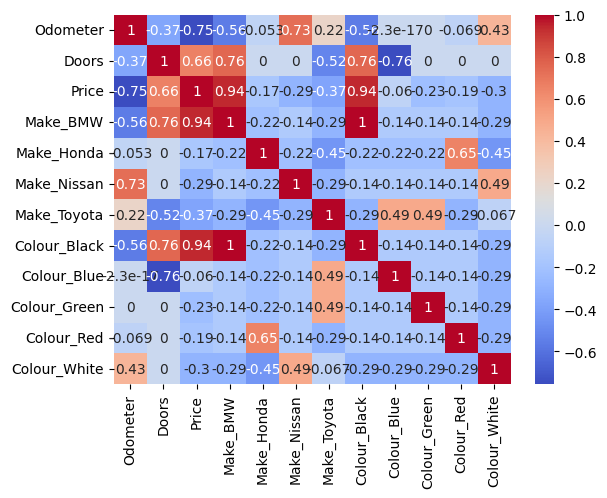

In [542]:
# ดู Correlation + Heatmap
df.corr()# ดู correlation ทุกคอลัมน์ numeric
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')# แสดงเป็น heatmap
plt.show()


---
## 📈 Part 4: Matplotlib & Seaborn — สร้างกราฟ

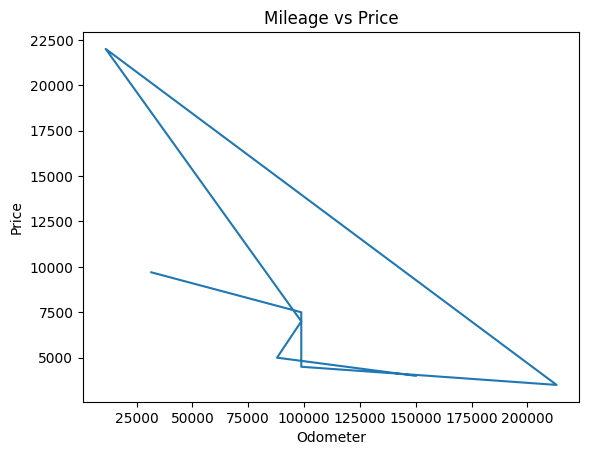

In [543]:
# Line Plot + Title + Labels
# ให้แกน x เป็น Odometer และ แกน y เป็น Price ของรถ
x = df["Odometer"]
y = df["Price"]

# วาดกราฟ Scatter (เพราะเป็นจุดๆ ไม่ได้ต่อเนื่องกันแบบเส้น)
plt.plot(x, y)
plt.title("Mileage vs Price")
plt.xlabel("Odometer")
plt.ylabel("Price")
plt.show()


<BarContainer object of 8 artists>

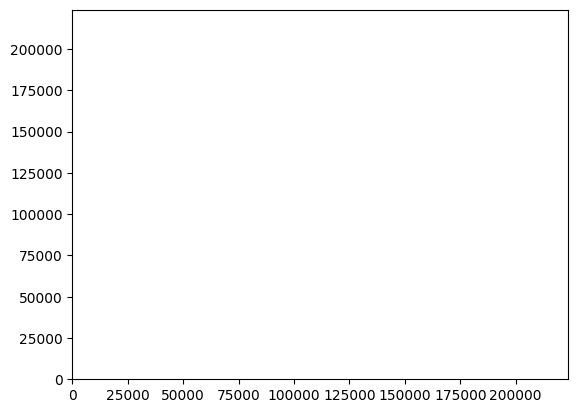

In [544]:
# Bar Chart (แนวตั้ง)
plt.bar(x, y)# แนวตั้ง
plt.barh(x, y)# แนวนอน

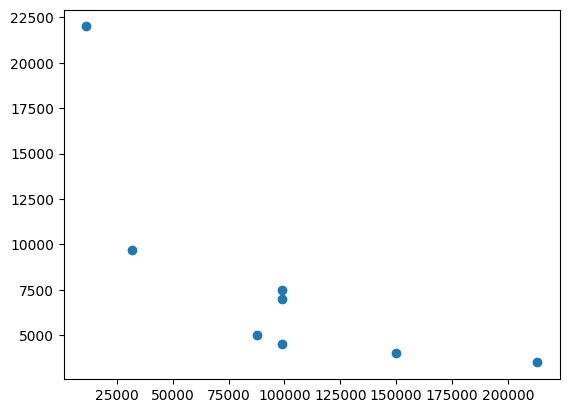

In [545]:
# Scatter Plot
plt.scatter(x, y)

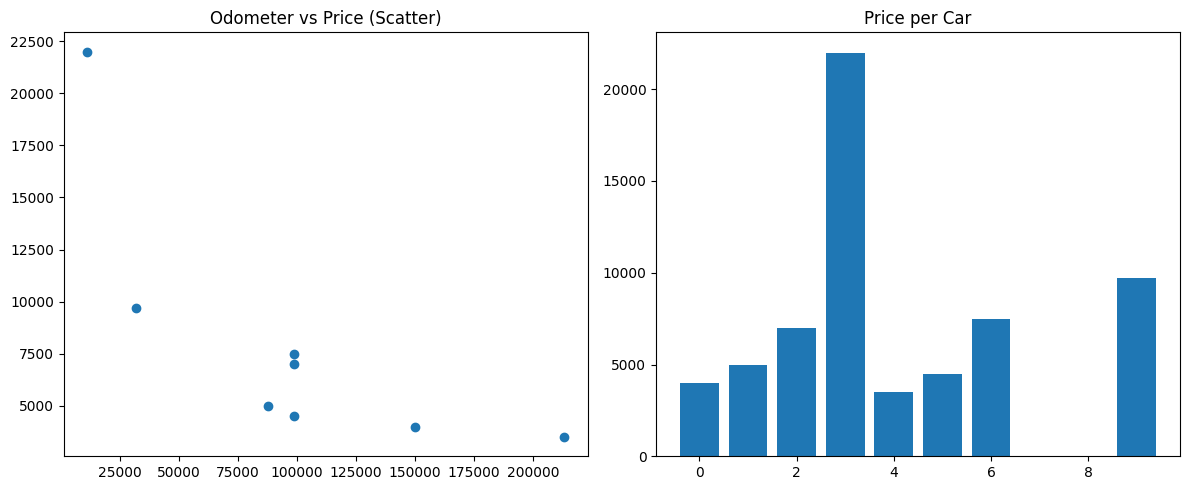

In [546]:
# Subplots — สร้าง 2 กราฟในรูปเดียว (1 แถว 2 คอลัมน์)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# กราฟ 1: แบบจุด (Scatter) จะดูรู้เรื่องกว่า
axes[0].scatter(x, y) 
axes[0].set_title("Odometer vs Price (Scatter)")

# กราฟ 2: ลองพล็อตแค่ราคา (y) เปล่าๆ ออกมาเป็นกราฟแท่ง
axes[1].bar(df.index, y) # ให้แกน x เป็น แถวที่ 0,1,2,3...
axes[1].set_title("Price per Car")

plt.tight_layout()
plt.show()


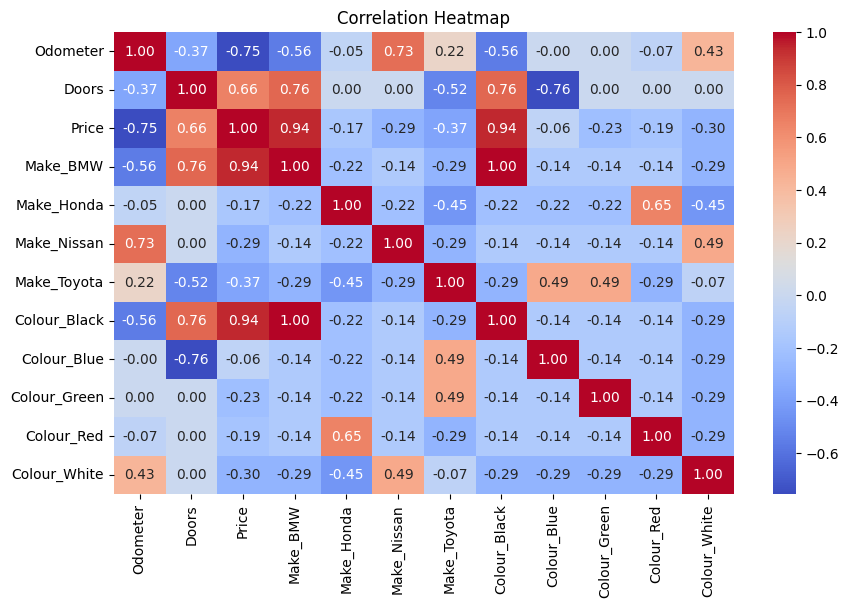

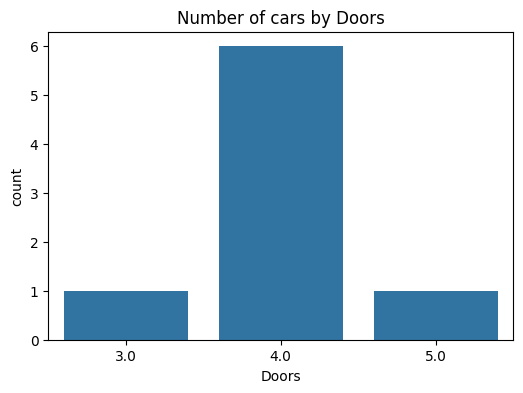

In [547]:
# Seaborn: Countplot
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Heatmap — เอาเฉพาะคอลัมน์ตัวเลขมาดู Correlation
plt.figure(figsize=(10, 6)) # ขยายขนาดหน่อยเผื่อคอลัมน์มันเยอะ
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 2. Countplot — นับจำนวนรถแต่ละยี่ห้อ (ถ้าแปลง Make เป็นเลข 0,1 ไปแล้วนับไม่ได้แล้วนะ!)
# สมมติว่ายังไม่ได้แปลง หรือถ้าแปลงแล้ว อยากนับจำนวน 'Doors' (ประตู) แทน ก็ใส่ 'Doors' ได้ครับ
plt.figure(figsize=(6, 4))
sns.countplot(x='Doors', data=df) 
plt.title("Number of cars by Doors")
plt.show()


---
## 🔧 Part 5: Data Preprocessing — เตรียมข้อมูลสำหรับ ML

In [548]:
# แบ่ง Features (X) กับ Target (y)
# Hint: X = df.drop("target", axis=1), y = df["target"]ง
X= df.drop("Price",axis=1)# Features = ทุกคอลัมน์ยกเว้น target
y = df['Price']


In [549]:
# แบ่ง Train / Test (80/20, random_state=42)
X_train, X_test, y_train, y_test= train_test_split(
    X, y,
test_size=0.2,# 20% เป็น test
random_state=42# ให้ผลคงที่ทุกครั้ง
)

In [550]:
# StandardScaler — fit_transform กับ train, transform กับ test
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)# fit + transform กับ train
X_test_scaled= scaler.transform(X_test)# transform อย่างเดียวกับ test

In [551]:
# MinMaxScaler — fit_transform กับ train, transform กับ test
scaler= MinMaxScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

---
## 📉 Part 6: Regression Models

สำหรับแต่ละ model: สร้าง → fit → predict → evaluate

In [552]:
# 6.1 Linear Regression
# สร้างโมเดล → fit → predict → ดู coef_ และ intercept_
from sklearn.linear_model import LinearRegression

model= LinearRegression()
model.fit(X_train, y_train)# เทรนโมเดล
y_pred= model.predict(X_test)# ทำนาย

# ดูค่า coefficient และ intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-4.31130049e-02  2.44934837e+03  3.28237049e+03 -1.70989262e+03
  1.62479482e+03 -5.93566364e+02  3.28237049e+03  8.33022116e+02
  0.00000000e+00  0.00000000e+00 -2.40549999e+03]
Intercept: 3670.477461290452


In [553]:
# 6.2 Polynomial Regression (degree=2)
# สร้าง PolynomialFeatures → fit_transform → LinearRegression → fit → predict
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# สร้าง polynomial features (เช่น degree=2 → x, x², x*y, ...)
poly= PolynomialFeatures(degree=2)
X_train_poly= poly.fit_transform(X_train)
X_test_poly= poly.transform(X_test)

# เทรนด้วย LinearRegression
model= LinearRegression()
model.fit(X_train_poly, y_train)
y_pred= model.predict(X_test_poly)

In [554]:
# 6.3 Ridge Regression (alpha=1.0)
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Ridge — L2 Regularization (ลด overfitting โดยลด weight)
ridge= Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred= ridge.predict(X_test)

In [555]:
# 6.4 Lasso Regression (alpha=0.1)
# Lasso — L1 Regularization (ลด weight บางตัวเป็น 0 = feature selection)
lasso= Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred= lasso.predict(X_test)

In [556]:
# 6.5 ElasticNet (alpha=0.1)
# ElasticNet — ผสม L1 + L2
enet= ElasticNet(alpha=0.1)
enet.fit(X_train, y_train)
y_pred= enet.predict(X_test)

In [557]:
# 6.6 DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Decision Tree Regressor
dt_reg= DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)
y_pred= dt_reg.predict(X_test)

In [558]:
# 6.7 SVR (ต้อง scale!)
# Support Vector Regression
svr= SVR()
svr.fit(X_train_scaled, y_train)# ⚠️ ต้อง scale
y_pred= svr.predict(X_test_scaled)

In [559]:
# 6.8 Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

model= RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred= model.predict(X_test)

In [560]:
# Regression Evaluation — คำนวณ MSE, RMSE, MAE, R²
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse= mean_squared_error(y_test, y_pred)# MSE — ค่ายิ่งน้อยยิ่งดี
rmse= np.sqrt(mse)# RMSE — root ของ MSE
mae= mean_absolute_error(y_test, y_pred)# MAE — ค่าเฉลี่ย error
r2= r2_score(y_test, y_pred)# R² — ยิ่งใกล้ 1 ยิ่งดี

print(f"MSE:{mse:.4f}")
print(f"RMSE:{rmse:.4f}")
print(f"MAE:{mae:.4f}")
print(f"R²:{r2:.4f}")

MSE:7850784.5000
RMSE:2801.9251
MAE:2798.5000
R²:-124.6126


---
## 🎯 Part 7: Classification Models

สำหรับแต่ละ model: สร้าง → fit → predict → evaluate

In [561]:
# # 7.1 k-NN (n_neighbors=5) — ต้อง scale!

# from sklearn.neighbors import KNeighborsClassifier

# model= KNeighborsClassifier(n_neighbors=5)# k=5 (จำนวนเพื่อนบ้าน)
# model.fit(X_train_scaled, y_train)# ⚠️ ต้อง scale ก่อน!
# y_pred= model.predict(X_test_scaled)

# # หา k ที่ดีที่สุดด้วย Cross-Validation
# best_k=5
# best_score=0
# for k in range(1,21):
#     knn= KNeighborsClassifier(n_neighbors=k)
#     scores= cross_val_score(knn, X_train_scaled, y_train,cv=5)
# if scores.mean()> best_score:
#         best_score= scores.mean()
#         best_k= k
# print(f"Best k ={best_k}, Score ={best_score:.4f}")

In [562]:
# 7.1 (ต่อ) หา k ที่ดีที่สุดด้วย loop + cross_val_score


In [563]:
# 7.2 Decision Tree (max_depth=3) — ไม่ต้อง scale


In [564]:
# 7.2 (ต่อ) แสดง Tree Rules ด้วย export_text


In [565]:
# 7.2 (ต่อ) หา max_depth ที่ดีที่สุดด้วย loop + cross_val_score


In [566]:
# 7.3 Logistic Regression (max_iter=1000)


In [567]:
# 7.4 SVC (kernel='rbf') — ต้อง scale!


In [568]:
# 7.5 Random Forest Classifier


In [569]:
# 7.5 (ต่อ) ดู Feature Importance ของ Random Forest
# Hint: model.feature_importances_


In [571]:
# Classification Evaluation — Accuracy, Precision, Recall, F1

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

acc= accuracy_score(y_test, y_pred)
prec= precision_score(y_test, y_pred,average='weighted')
rec= recall_score(y_test, y_pred,average='weighted')
f1= f1_score(y_test, y_pred,average='weighted')

print(f"Accuracy:{acc:.4f}")
print(f"Precision:{prec:.4f}")
print(f"Recall:{rec:.4f}")
print(f"F1 Score:{f1:.4f}")

# Confusion Matrix
cm= confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report (รวม precision, recall, f1 ทุก class)
print(classification_report(y_test, y_pred))

Accuracy:0.0000
Precision:0.0000
Recall:0.0000
F1 Score:0.0000
Confusion Matrix:
 [[0 0 1 0]
 [0 0 0 1]
 [0 0 0 0]
 [0 0 0 0]]
              precision    recall  f1-score   support

      4500.0       0.00      0.00      0.00       1.0
      5000.0       0.00      0.00      0.00       1.0
      7160.0       0.00      0.00      0.00       0.0
      7937.0       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{

In [ ]:
# Confusion Matrix


In [ ]:
# Classification Report


Mean:nan, Std:nan


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


ValueError: n_splits=5 cannot be greater than the number of members in each class.

In [ ]:
# Cross-Validation (cv=5)


In [ ]:
# StratifiedKFold (n_splits=5, shuffle=True, random_state=42)


---
## 🧠 Part 8: Deep Learning — Neural Network

### 8A: Regression ด้วย Neural Network

In [ ]:
# สร้างโมเดล Sequential สำหรับ Regression
# - Hidden Layer 1: 64 nodes, relu
# - Dropout 0.3
# - Hidden Layer 2: 32 nodes, relu
# - Output Layer: 1 node (ไม่มี activation)


In [ ]:
# model.summary() — ดูโครงสร้าง


In [ ]:
# Compile — optimizer=Adam(lr=0.001), loss='mse', metrics=['mae']


In [ ]:
# Train — epochs=50, batch_size=32, validation_split=0.2


In [ ]:
# ทำนาย


In [ ]:
# Plot Training History (loss + val_loss)


### 8B: Binary Classification ด้วย Neural Network

In [ ]:
# สร้างโมเดล Sequential สำหรับ Binary Classification
# - Output Layer: 1 node, activation='sigmoid'
# - loss='binary_crossentropy'


In [ ]:
# Compile + Train


### 8C: Multiclass Classification ด้วย Neural Network

In [ ]:
# แปลง y เป็น One-Hot ด้วย to_categorical


In [ ]:
# สร้างโมเดล Multiclass
# - Output Layer: num_classes nodes, activation='softmax'
# - loss='categorical_crossentropy'


In [ ]:
# Compile + Train


In [ ]:
# ทำนาย + แปลงกลับด้วย np.argmax


---
## 📏 Part 9: Evaluation Metrics — เขียนให้ครบ

### Regression Metrics

In [ ]:
# คำนวณ MSE

# คำนวณ RMSE (Hint: np.sqrt)

# คำนวณ MAE

# คำนวณ R²


### Classification Metrics

In [ ]:
# คำนวณ Accuracy

# คำนวณ Precision (average='weighted')

# คำนวณ Recall (average='weighted')

# คำนวณ F1 Score (average='weighted')


In [ ]:
# Confusion Matrix


In [ ]:
# Classification Report


### Clustering Metrics

In [ ]:
# Silhouette Score (ยิ่งใกล้ 1 ยิ่งดี)

# Calinski-Harabasz Score (ยิ่งสูงยิ่งดี)

# Davies-Bouldin Score (ยิ่งน้อยยิ่งดี)


### Distance Metrics

In [ ]:
# Euclidean Distance

# Cosine Distance


---
## 🔑 Part 10: สรุป — ตอบคำถาม

ตอบคำถามเหล่านี้ด้วยตัวเอง:

**Q1:** Model ไหนต้อง Scale ข้อมูล? Model ไหนไม่ต้อง?

ตอบ: ...

**Q2:** ถ้าทำ Binary Classification ด้วย Neural Network — Output layer ต้องใช้ activation อะไร? Loss function อะไร?

ตอบ: ...

**Q3:** ถ้าทำ Multiclass Classification ด้วย Neural Network — Output layer ต้องใช้ activation อะไร? Loss function อะไร? ต้องแปลง y เป็นอะไรก่อน?

ตอบ: ...

**Q4:** StandardScaler กับ MinMaxScaler ต่างกันยังไง?

ตอบ: ...

**Q5:** ทำไมห้าม fit_transform กับ test set?

ตอบ: ...

**Q6:** Confusion Matrix — TP, FP, FN, TN คืออะไร?

ตอบ: ...

**Q7:** Ridge vs Lasso vs ElasticNet ต่างกันยังไง?

ตอบ: ...

**Q8:** Cross-Validation คืออะไร? StratifiedKFold ต่างจาก KFold ปกติยังไง?

ตอบ: ...